 #  Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/shopping_trends.csv")

df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [4]:
df.shape

(3900, 19)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   object 
 3   Item Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   object 
 12  Payment Method            3900 non-null   object 
 13  Shipping Type             3900 non-null   object 
 14  Discount

In [6]:
df.isnull().sum()

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
df.nunique().sort_values()

Promo Code Used                2
Gender                         2
Discount Applied               2
Subscription Status            2
Season                         4
Category                       4
Size                           4
Shipping Type                  6
Payment Method                 6
Preferred Payment Method       6
Frequency of Purchases         7
Color                         25
Item Purchased                25
Review Rating                 26
Location                      50
Previous Purchases            50
Age                           53
Purchase Amount (USD)         81
Customer ID                 3900
dtype: int64

# Exploratory Data Analysis

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Customer ID,3900.0,1950.500000,1125.977353,1.0,975.75,1950.5,2925.25,3900.0
Age,3900.0,44.068462,15.207589,18.0,31.00,44.0,57.00,70.0
Purchase Amount (USD),3900.0,59.764359,23.685392,20.0,39.00,60.0,81.00,100.0
Review Rating,3900.0,3.749949,0.716223,2.5,3.10,3.7,4.40,5.0
Previous Purchases,3900.0,25.351538,14.447125,1.0,13.00,25.0,38.00,50.0


In [10]:
for col in df.select_dtypes("object").columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- Gender ---
Gender
Male      2652
Female    1248
Name: count, dtype: int64

--- Item Purchased ---
Item Purchased
Blouse        171
Jewelry       171
Pants         171
Shirt         169
Dress         166
Sweater       164
Jacket        163
Belt          161
Sunglasses    161
Coat          161
Sandals       160
Socks         159
Skirt         158
Shorts        157
Scarf         157
Hat           154
Handbag       153
Hoodie        151
Shoes         150
T-shirt       147
Sneakers      145
Boots         144
Backpack      143
Gloves        140
Jeans         124
Name: count, dtype: int64

--- Category ---
Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64

--- Location ---
Location
Montana           96
California        95
Idaho             93
Illinois          92
Alabama           89
Minnesota         88
Nebraska          87
New York          87
Nevada            87
Maryland          86
Delaware          86
Vermont        

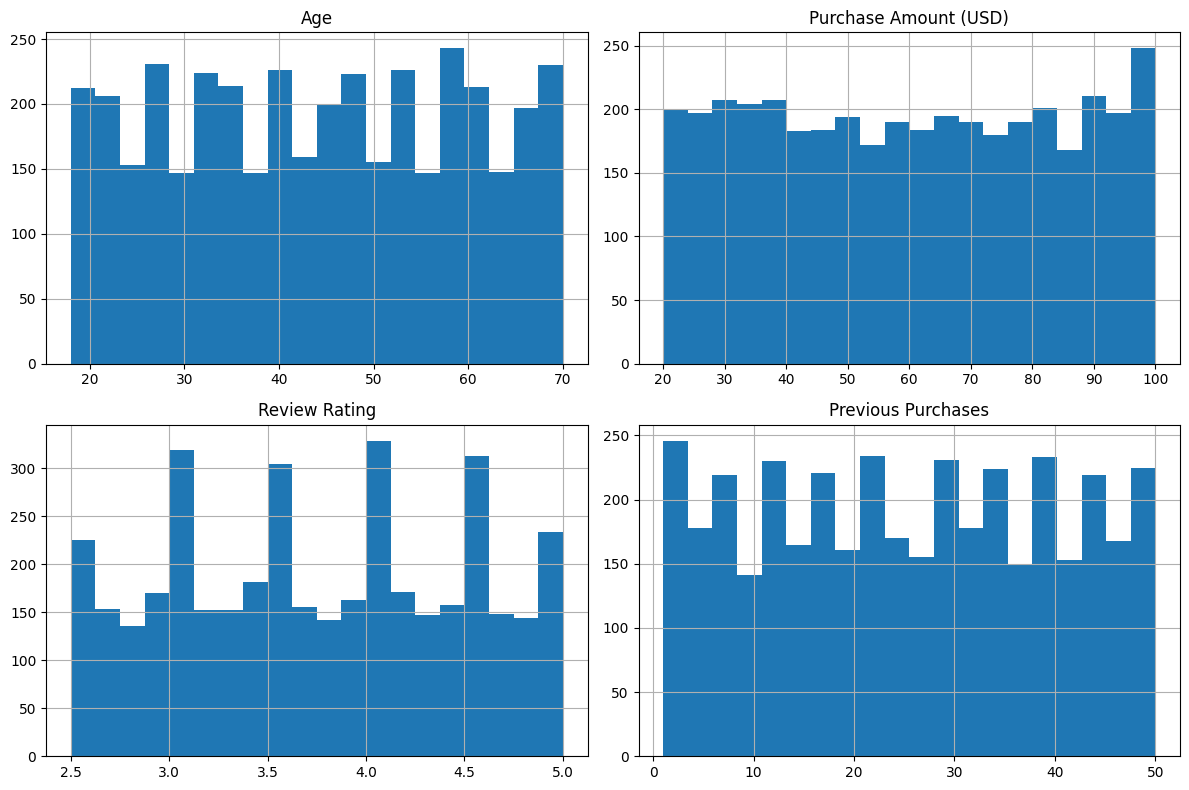

In [11]:
df[[
    "Age",
    "Purchase Amount (USD)",
    "Review Rating",
    "Previous Purchases"
]].hist(figsize=(12, 8), bins=20)

plt.tight_layout()
plt.show()

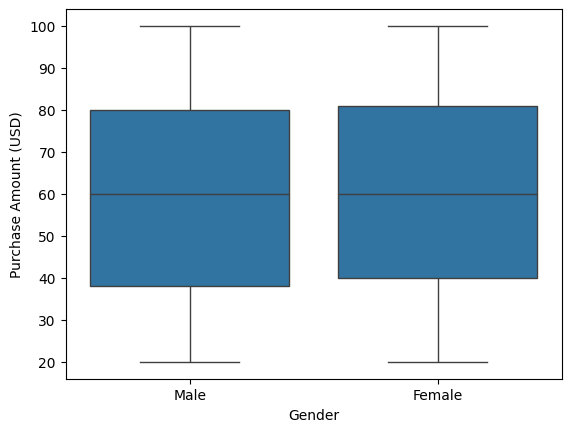

In [13]:
sns.boxplot(data=df, x="Gender", y="Purchase Amount (USD)")
plt.show()

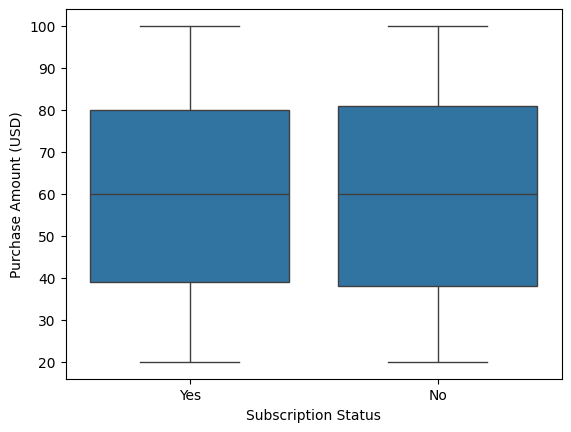

In [14]:
sns.boxplot(data=df, x="Subscription Status", y="Purchase Amount (USD)")
plt.show()

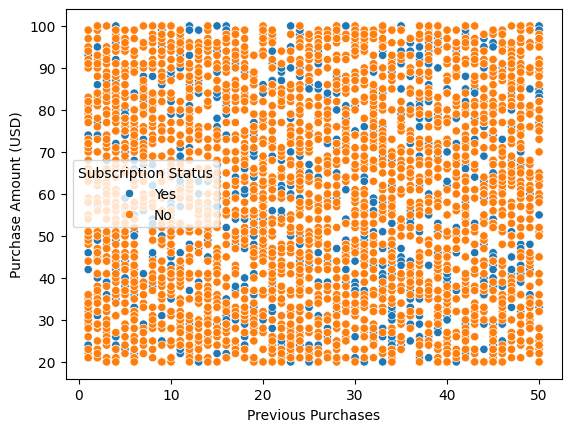

In [15]:
sns.scatterplot(
    data=df,
    x="Previous Purchases",
    y="Purchase Amount (USD)",
    hue="Subscription Status"
)
plt.show()

In [16]:
df[[
    "Age",
    "Purchase Amount (USD)",
    "Review Rating",
    "Previous Purchases"
]].corr()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
Age,1.000000,-0.010424,-0.021949,0.040445
Purchase Amount (USD),-0.010424,1.000000,0.030776,0.008063
Review Rating,-0.021949,0.030776,1.000000,0.004229
Previous Purchases,0.040445,0.008063,0.004229,1.000000


In [17]:
df.groupby("Category")["Purchase Amount (USD)"].agg(
    ["count", "mean", "median", "std"]
).sort_values("mean", ascending=False)

,count,mean,median,std
Category,,,,
Footwear,599,60.255426,60.0,23.638439
Clothing,1737,60.025331,60.0,23.792460
Accessories,1240,59.838710,60.0,23.301230
Outerwear,324,57.172840,54.5,24.590033


In [18]:
df["Frequency of Purchases"].value_counts()

Frequency of Purchases
Every 3 Months    584
Annually          572
Quarterly         563
Monthly           553
Bi-Weekly         547
Fortnightly       542
Weekly            539
Name: count, dtype: int64

In [19]:
df.groupby("Frequency of Purchases")["Purchase Amount (USD)"].agg(
    ["count", "mean", "median", "std"]
).sort_values("mean", ascending=False)

,count,mean,median,std
Frequency of Purchases,,,,
Bi-Weekly,547,60.694698,63.0,23.736111
Annually,572,60.173077,59.0,23.969474
Every 3 Months,584,60.082192,60.0,23.991138
Quarterly,563,59.984014,61.0,23.832260
Monthly,553,59.330922,58.0,23.056894
Fortnightly,542,59.053506,58.5,23.857767
Weekly,539,58.972171,58.0,23.381855


In [20]:
df.groupby("Frequency of Purchases")["Previous Purchases"].agg(
    ["count", "mean", "median", "std"]
).sort_values("mean", ascending=False)

,count,mean,median,std
Frequency of Purchases,,,,
Quarterly,563,26.854352,28.0,14.638227
Weekly,539,25.771800,26.0,14.516042
Monthly,553,25.278481,25.0,14.070160
Fortnightly,542,25.271218,26.0,14.278270
Every 3 Months,584,24.960616,24.0,14.902202
Bi-Weekly,547,24.787934,24.0,14.573635
Annually,572,24.561189,24.0,14.068064


In [ ]:
df.groupby("Subscription Status")["Purchase Amount (USD)"].agg(
    ["count", "mean", "median", "std"]
)


df.groupby("Frequency of Purchases")["Previous Purchases"].agg(
    ["count", "mean", "median", "std"]
).sort_values("mean", ascending=False)

,count,mean,median,std
Frequency of Purchases,,,,
Quarterly,563,26.854352,28.0,14.638227
Weekly,539,25.771800,26.0,14.516042
Monthly,553,25.278481,25.0,14.070160
Fortnightly,542,25.271218,26.0,14.278270
Every 3 Months,584,24.960616,24.0,14.902202
Bi-Weekly,547,24.787934,24.0,14.573635
Annually,572,24.561189,24.0,14.068064


In [22]:
df.groupby("Gender")["Purchase Amount (USD)"].agg(
    ["count", "mean", "median", "std"])

,count,mean,median,std
Gender,,,,
Female,1248,60.249199,60.0,23.420556
Male,2652,59.536199,60.0,23.809976


In [23]:
df.groupby("Subscription Status")["Purchase Amount (USD)"].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
Subscription Status,,,,
No,2847,59.865121,60.0,23.775199
Yes,1053,59.491928,60.0,23.449914


# Feature Engineering

In [24]:
features = df[[
    "Age",
    "Purchase Amount (USD)",
    "Review Rating",
    "Previous Purchases"
]].copy()

features.head()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
0,55,53,3.1,14
1,19,64,3.1,2
2,50,73,3.1,23
3,21,90,3.5,49
4,45,49,2.7,31


In [25]:
frequency_map = {
    "Weekly": 52,
    "Bi-Weekly": 26,
    "Fortnightly": 26,
    "Monthly": 12,
    "Quarterly": 4,
    "Every 3 Months": 4,
    "Annually": 1
}

features["Purchase Frequency"] = df["Frequency of Purchases"].map(frequency_map)

features.head()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases,Purchase Frequency
0,55,53,3.1,14,26
1,19,64,3.1,2,26
2,50,73,3.1,23,52
3,21,90,3.5,49,52
4,45,49,2.7,31,1


In [26]:
features["Is_Subscribed"] = df["Subscription Status"].map({
    "Yes": 1,
    "No": 0
})

features["Discount_Applied"] = df["Discount Applied"].map({
    "Yes": 1,
    "No": 0
})

features["Promo_Used"] = df["Promo Code Used"].map({
    "Yes": 1,
    "No": 0
})

features.head()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases,Purchase Frequency,Is_Subscribed,Discount_Applied,Promo_Used
0,55,53,3.1,14,26,1,1,1
1,19,64,3.1,2,26,1,1,1
2,50,73,3.1,23,52,1,1,1
3,21,90,3.5,49,52,1,1,1
4,45,49,2.7,31,1,1,1,1


In [27]:
features.info()
features.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    3900 non-null   int64  
 1   Purchase Amount (USD)  3900 non-null   int64  
 2   Review Rating          3900 non-null   float64
 3   Previous Purchases     3900 non-null   int64  
 4   Purchase Frequency     3900 non-null   int64  
 5   Is_Subscribed          3900 non-null   int64  
 6   Discount_Applied       3900 non-null   int64  
 7   Promo_Used             3900 non-null   int64  
dtypes: float64(1), int64(7)
memory usage: 243.9 KB


,count,mean,std,min,25%,50%,75%,max
Age,3900.0,44.068462,15.207589,18.0,31.0,44.0,57.0,70.0
Purchase Amount (USD),3900.0,59.764359,23.685392,20.0,39.0,60.0,81.0,100.0
Review Rating,3900.0,3.749949,0.716223,2.5,3.1,3.7,4.4,5.0
Previous Purchases,3900.0,25.351538,14.447125,1.0,13.0,25.0,38.0,50.0
Purchase Frequency,3900.0,17.471282,16.809646,1.0,4.0,12.0,26.0,52.0
Is_Subscribed,3900.0,0.270000,0.444016,0.0,0.0,0.0,1.0,1.0
Discount_Applied,3900.0,0.430000,0.495139,0.0,0.0,0.0,1.0,1.0
Promo_Used,3900.0,0.430000,0.495139,0.0,0.0,0.0,1.0,1.0


In [28]:
df.select_dtypes("object").nunique().sort_values()

Gender                       2
Subscription Status          2
Discount Applied             2
Promo Code Used              2
Category                     4
Size                         4
Season                       4
Payment Method               6
Shipping Type                6
Preferred Payment Method     6
Frequency of Purchases       7
Item Purchased              25
Color                       25
Location                    50
dtype: int64

In [29]:
df.select_dtypes("object").columns

Index(['Gender', 'Item Purchased', 'Category', 'Location', 'Size', 'Color',
       'Season', 'Subscription Status', 'Payment Method', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Preferred Payment Method',
       'Frequency of Purchases'],
      dtype='object')

In [35]:
categorical_features = [
    "Category",
    "Size",
    "Season",
    "Payment Method",
    "Shipping Type"
]

categorical_df = pd.get_dummies(
    df[categorical_features],
    drop_first=False,dtype=int
)

categorical_df.head()

,Category_Accessories,Category_Clothing,Category_Footwear,Category_Outerwear,Size_L,Size_M,Size_S,Size_XL,Season_Fall,Season_Spring,...,Payment Method_Credit Card,Payment Method_Debit Card,Payment Method_PayPal,Payment Method_Venmo,Shipping Type_2-Day Shipping,Shipping Type_Express,Shipping Type_Free Shipping,Shipping Type_Next Day Air,Shipping Type_Standard,Shipping Type_Store Pickup
0,0,1,0,0,1,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,0
1,0,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,0,1,0,0,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,0,0
3,0,0,1,0,0,1,0,0,0,1,...,0,0,1,0,0,0,0,1,0,0
4,0,1,0,0,0,1,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0


In [36]:
categorical_df.shape

(3900, 24)

In [37]:
features_final = pd.concat(
    [features, categorical_df],
    axis=1
)

features_final.shape

(3900, 32)

In [38]:
features_final.head()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases,Purchase Frequency,Is_Subscribed,Discount_Applied,Promo_Used,Category_Accessories,Category_Clothing,...,Payment Method_Credit Card,Payment Method_Debit Card,Payment Method_PayPal,Payment Method_Venmo,Shipping Type_2-Day Shipping,Shipping Type_Express,Shipping Type_Free Shipping,Shipping Type_Next Day Air,Shipping Type_Standard,Shipping Type_Store Pickup
0,55,53,3.1,14,26,1,1,1,0,1,...,1,0,0,0,0,1,0,0,0,0
1,19,64,3.1,2,26,1,1,1,0,1,...,0,0,0,0,0,1,0,0,0,0
2,50,73,3.1,23,52,1,1,1,0,1,...,0,0,0,0,0,0,1,0,0,0
3,21,90,3.5,49,52,1,1,1,0,0,...,0,0,1,0,0,0,0,1,0,0
4,45,49,2.7,31,1,1,1,1,0,1,...,0,0,0,0,0,0,1,0,0,0


In [39]:
features_final.dtypes.value_counts()

int32      24
int64       7
float64     1
Name: count, dtype: int64

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(features_final)

# Clustering

In [41]:
from sklearn.cluster import KMeans

inertias = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

C:\Users\21626\AppData\Roaming\Python\Python38\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Le fichier spécifié est introuvable
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\21626\AppData\Roaming\Python\Python38\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Program Files\Python38\lib\subprocess.py", line 489, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Program Files\Python38\lib\subprocess.py", line 854, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Program Files\Python38\lib\subprocess.py", line 1307, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


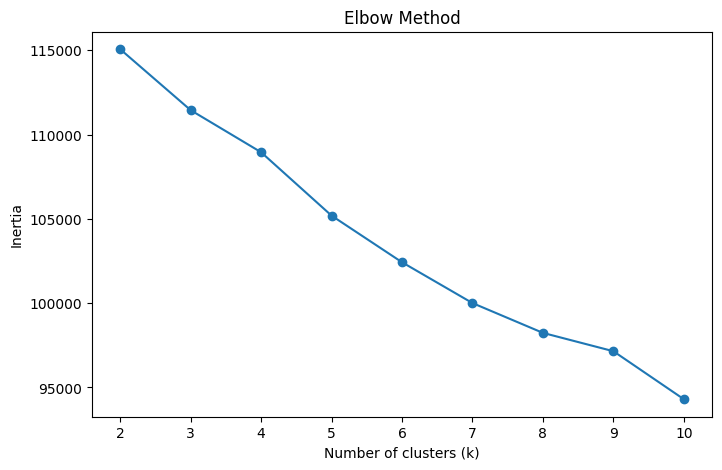

In [42]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [43]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

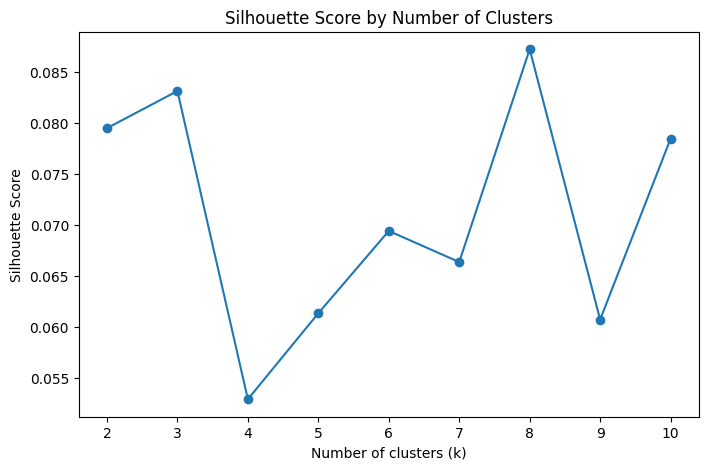

In [44]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.show()

In [46]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

In [47]:
df["Cluster"] = clusters

In [48]:
df["Cluster"].value_counts().sort_index()

Cluster
0     324
1    1533
2    2043
Name: count, dtype: int64

In [49]:
cluster_profile = df.groupby("Cluster")[[
    "Age",
    "Purchase Amount (USD)",
    "Review Rating",
    "Previous Purchases"
]].agg(["mean", "median"])

cluster_profile

Age        Purchase Amount (USD)        Review Rating         \
              mean median                  mean median          mean median   
Cluster                                                                       
0        44.311728   45.0             57.172840   54.5      3.746914    3.8   
1        44.054795   43.0             59.651011   60.0      3.742140    3.7   
2        44.040137   44.0             60.260401   60.0      3.756290    3.8   

        Previous Purchases         
                      mean median  
Cluster                            
0                24.956790   25.0  
1                25.675799   25.0  
2                25.170827   25.0

In [50]:
df["Purchase Frequency"] = features["Purchase Frequency"]
df.groupby("Cluster")["Purchase Frequency"].agg(
    ["mean", "median", "std"]
)

,mean,median,std
Cluster,,,
0,17.669753,12.0,16.817327
1,17.456621,12.0,16.739955
2,17.450808,12.0,16.868533


In [51]:
pd.crosstab(
    df["Cluster"],
    df["Category"],
    normalize="index"
).round(3)

Category,Accessories,Clothing,Footwear,Outerwear
Cluster,,,,
0,0.000,0.000,0.000,1.0
1,0.354,0.477,0.169,0.0
2,0.341,0.492,0.166,0.0


In [52]:
categorical_cols = [
    "Size",
    "Season",
    "Payment Method",
    "Shipping Type"
]

for col in categorical_cols:
    print(f"\n===== {col} =====")
    print(
        pd.crosstab(
            df["Cluster"],
            df[col],
            normalize="index"
        ).round(3)
    )


===== Size =====
Size         L      M      S     XL
Cluster                            
0        0.287  0.457  0.173  0.083
1        0.273  0.440  0.180  0.107
2        0.265  0.456  0.162  0.116

===== Season =====
Season    Fall  Spring  Summer  Winter
Cluster                               
0        0.272   0.250   0.231   0.247
1        0.233   0.265   0.254   0.247
2        0.259   0.250   0.240   0.251

===== Payment Method =====
Payment Method  Bank Transfer   Cash  Credit Card  Debit Card  PayPal  Venmo
Cluster                                                                     
0                       0.139  0.191        0.148       0.188   0.160  0.173
1                       0.164  0.174        0.179       0.159   0.156  0.170
2                       0.164  0.157        0.183       0.161   0.170  0.165

===== Shipping Type =====
Shipping Type  2-Day Shipping  Express  Free Shipping  Next Day Air  Standard  \
Cluster                                                           

In [56]:
cluster_means = features_final.copy()
cluster_means["Cluster"] = df["Cluster"]

means = cluster_means.groupby("Cluster").mean()

# Écart maximal entre les clusters pour chaque variable
feature_difference = means.max() - means.min()

feature_difference = (
    feature_difference
    .sort_values(ascending=False)
)

feature_difference.head(15)

Purchase Amount (USD)          3.087562
Category_Outerwear             1.000000
Discount_Applied               1.000000
Promo_Used                     1.000000
Previous Purchases             0.719009
Is_Subscribed                  0.627528
Category_Clothing              0.492413
Category_Accessories           0.354207
Age                            0.271591
Purchase Frequency             0.218945
Category_Footwear              0.168950
Season_Fall                    0.038728
Shipping Type_Free Shipping    0.035104
Payment Method_Credit Card     0.034916
Payment Method_Cash            0.034726
dtype: float64

In [57]:
top_features = feature_difference.head(10).index

means[top_features]

,Purchase Amount (USD),Category_Outerwear,Discount_Applied,Promo_Used,Previous Purchases,Is_Subscribed,Category_Clothing,Category_Accessories,Age,Purchase Frequency
Cluster,,,,,,,,,,
0,57.172840,1.0,0.444444,0.444444,24.956790,0.280864,0.000000,0.000000,44.311728,17.669753
1,59.651011,0.0,1.000000,1.000000,25.675799,0.627528,0.476843,0.354207,44.054795,17.456621
2,60.260401,0.0,0.000000,0.000000,25.170827,0.000000,0.492413,0.341165,44.040137,17.450808


In [58]:
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

labels = df["Cluster"]

silhouette = silhouette_score(X_scaled, labels)
calinski = calinski_harabasz_score(X_scaled, labels)
davies = davies_bouldin_score(X_scaled, labels)

print("Silhouette Score:", silhouette)
print("Calinski-Harabasz Score:", calinski)
print("Davies-Bouldin Score:", davies)

Silhouette Score: 0.08312016381307934
Calinski-Harabasz Score: 233.38168836307023
Davies-Bouldin Score: 3.0904453844902977


In [59]:
behavior_features = features[
    [
        "Age",
        "Purchase Amount (USD)",
        "Review Rating",
        "Previous Purchases",
        "Purchase Frequency",
        "Is_Subscribed",
        "Discount_Applied",
        "Promo_Used"
    ]
].copy()

In [60]:
from sklearn.preprocessing import StandardScaler

scaler_behavior = StandardScaler()

X_behavior = scaler_behavior.fit_transform(behavior_features)

In [61]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

results = []

for k in range(2, 8):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = model.fit_predict(X_behavior)
    score = silhouette_score(X_behavior, labels)
    
    results.append((k, score))

results

[(2, 0.302171660174895),
 (3, 0.25167772019979007),
 (4, 0.17681228063379237),
 (5, 0.1853743891264907),
 (6, 0.17975340519037714),
 (7, 0.17925123079293717)]

In [62]:
kmeans_behavior = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

behavior_clusters = kmeans_behavior.fit_predict(X_behavior)

df["Behavior_Cluster"] = behavior_clusters

In [64]:
behavior_profile = features.copy()
behavior_profile["Behavior_Cluster"] = behavior_clusters

behavior_profile.groupby("Behavior_Cluster").mean().round(2)

,Age,Purchase Amount (USD),Review Rating,Previous Purchases,Purchase Frequency,Is_Subscribed,Discount_Applied,Promo_Used
Behavior_Cluster,,,,,,,,
0,44.14,59.28,3.74,25.74,17.56,0.63,1.0,1.0
1,44.01,60.13,3.76,25.06,17.41,0.00,0.0,0.0


In [65]:
behavior_profile["Behavior_Cluster"].value_counts()

Behavior_Cluster
1    2223
0    1677
Name: count, dtype: int64

In [67]:
behavior_profile["Behavior_Cluster"].value_counts(normalize=True).round(3)

Behavior_Cluster
1    0.57
0    0.43
Name: proportion, dtype: float64

L'analyse exploratoire et le clustering comportemental montrent que les principaux segments identifiés sont essentiellement différenciés par les variables Discount Applied, Promo Code Used et Subscription Status. Les variables numériques présentent des profils très proches entre les clusters, ce qui limite l'interprétation de segments clients plus complexes.